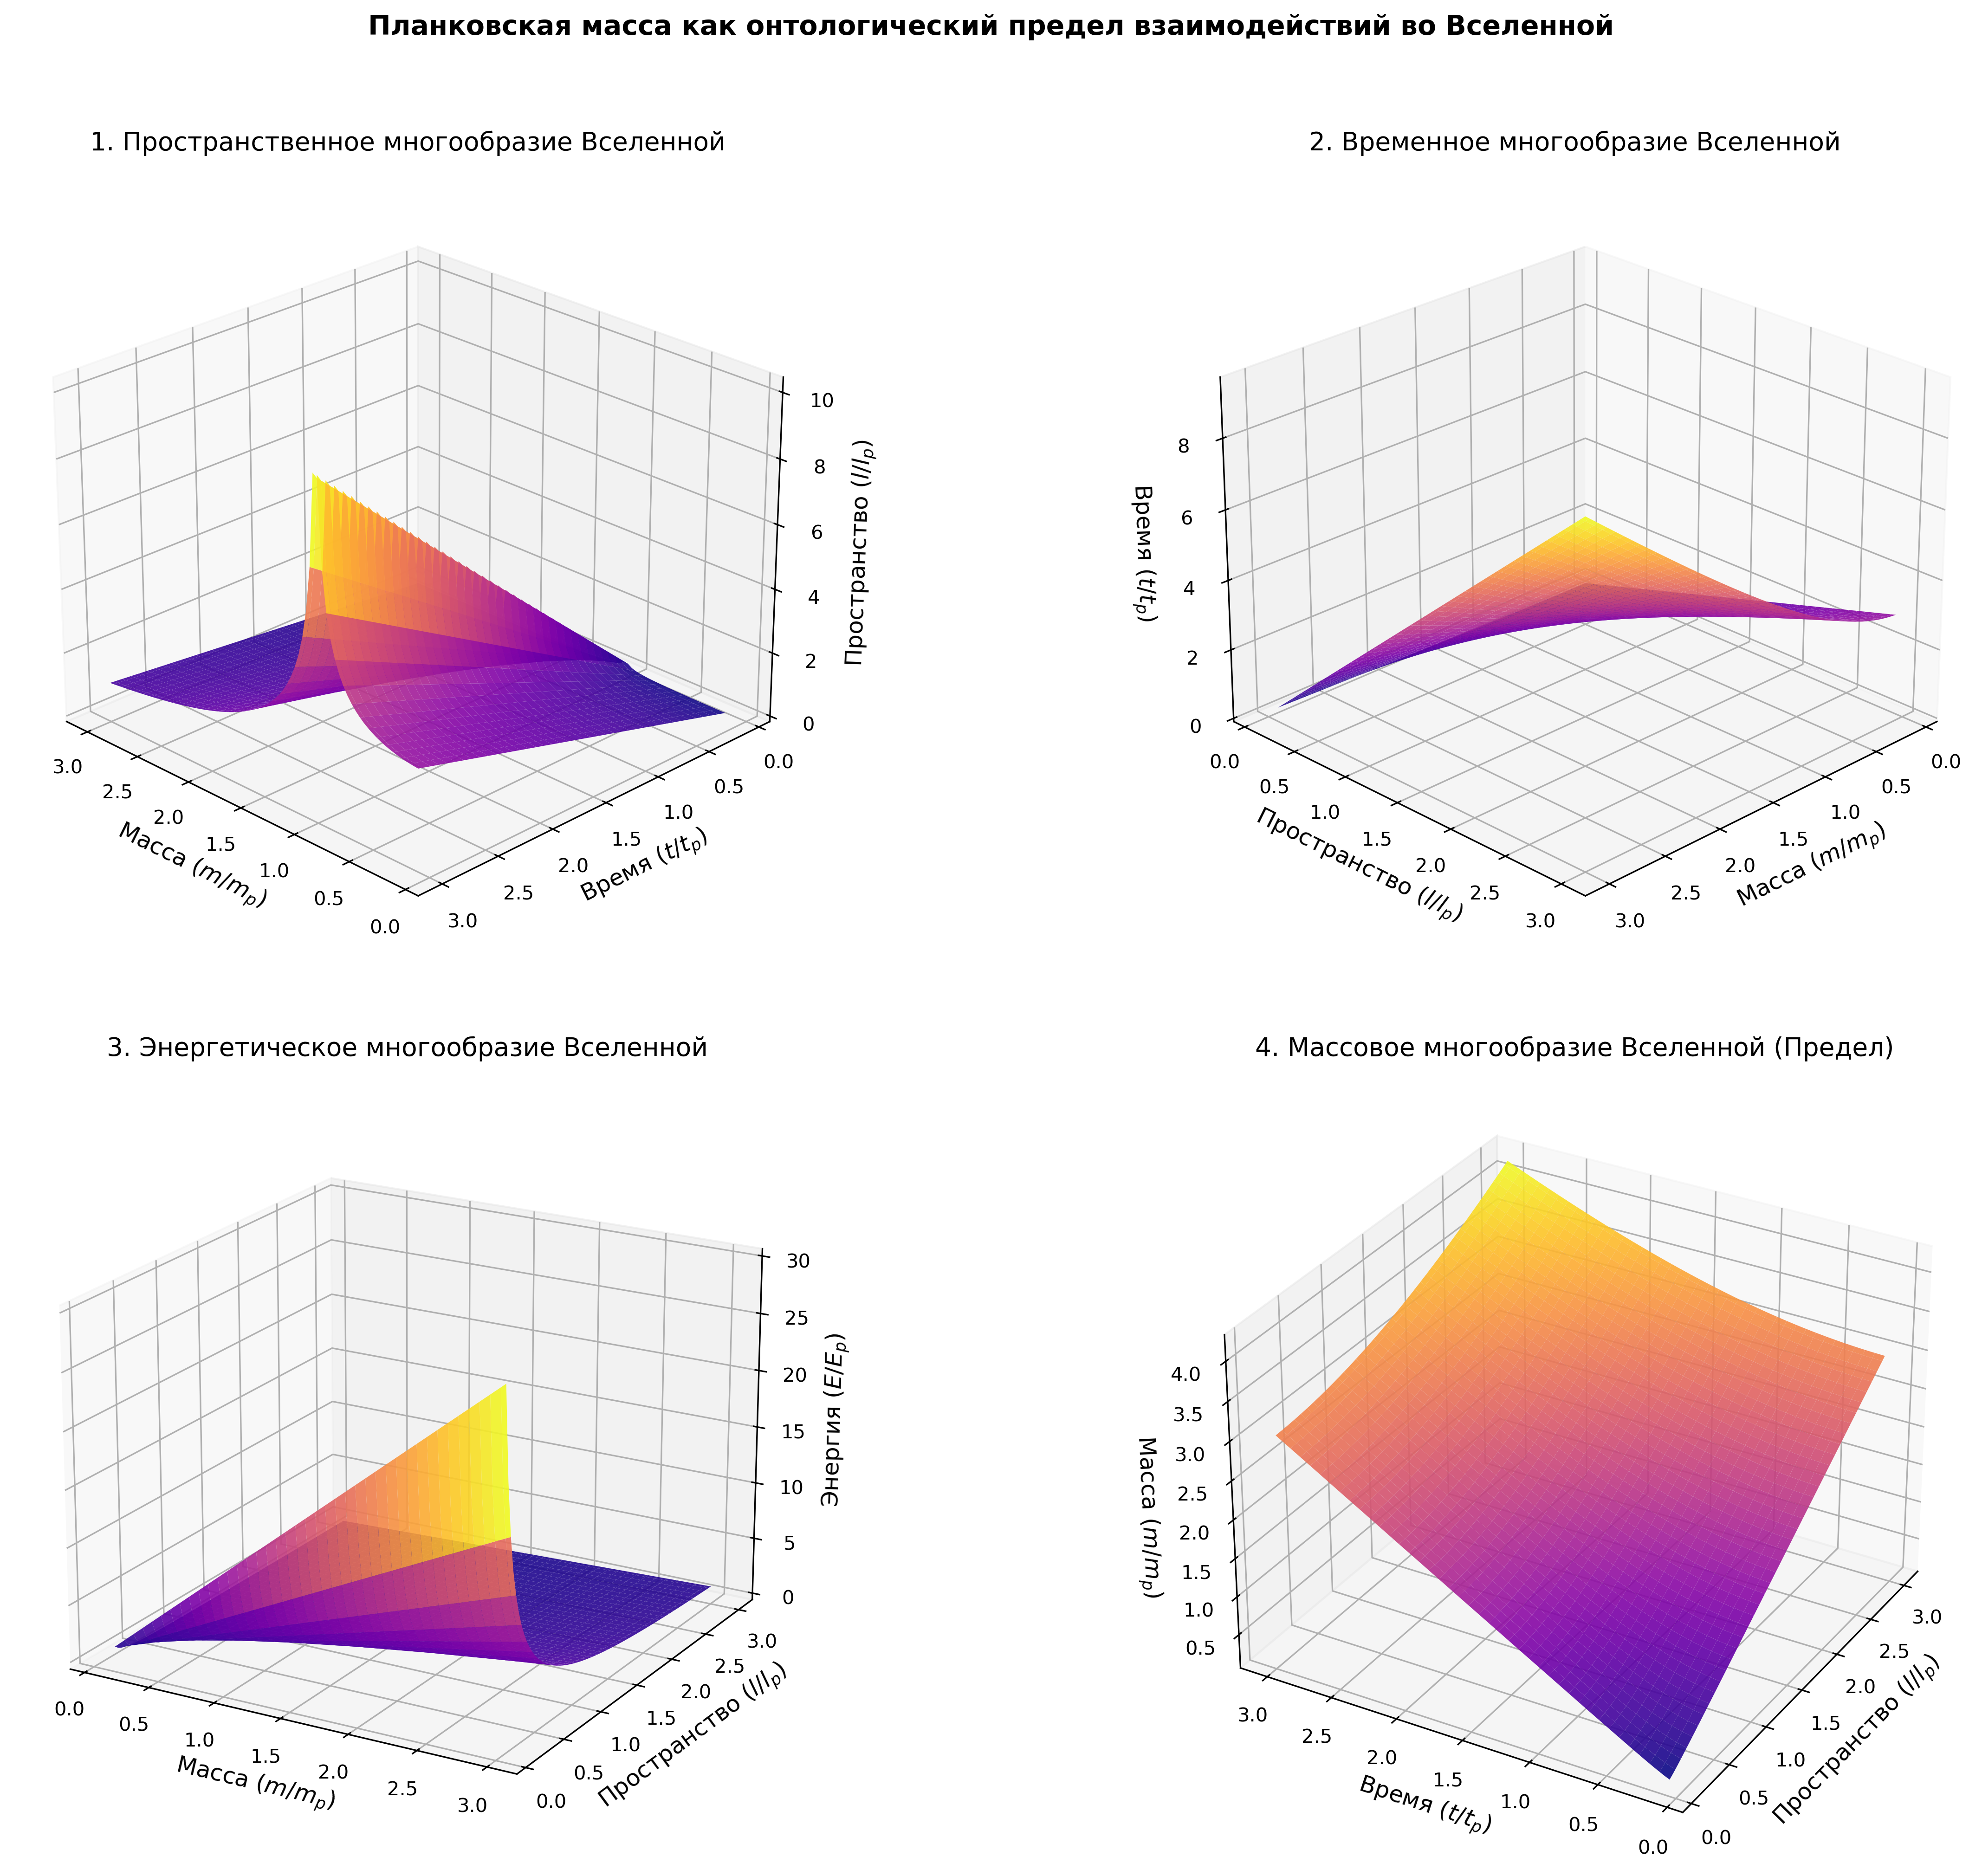

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Настройка академического стиля для публикаций
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'text.usetex': False  # Переключите в True, если в системе настроен LaTeX
})

# Сетка данных (в планковских единицах: от 0.1 до 3.0 m_p / l_p / t_p)
# Исключаем чистый ноль во избежание деления на ноль
x = np.linspace(0.1, 3.0, 80)
y = np.linspace(0.1, 3.0, 80)
X, Y = np.meshgrid(x, y)

# Моделирование физических зависимостей с граничным условием на планковской массе (M = 1)
# Граница взаимодействия аппроксимируется через релятивистские и квантовые эффекты
# Z1: Пространство l(m, t) = t / sqrt(|m^2 - 1| + eps) -> сингулярность на границе масс
eps = 0.05
Z_space = Y / np.sqrt(np.abs(X**2 - 1) + eps) 

# Z2: Время t(m, l) = l * sqrt(m^2 + 1) -> замедление процессов вблизи планковской массы
Z_time = Y * np.sqrt(X**2 + 1)

# Z3: Энергия E(m, l) = m / l -> классическая и квантовая концентрация энергии
Z_energy = X / Y

# Z4: Масса m(l, t) = sqrt(l^2 + t^2) -> геометрия связи пространства-времени порождает массу
Z_mass = np.sqrt(X**2 + Y**2)

# Создание фигуры с четырьмя 3D-субграфиками
fig = plt.figure(figsize=(16, 14), dpi=300)
cmap_style = 'plasma'  # Строгая, контрастная палитра для печати и экранов

# --- График 1: Многообразие Пространства ---
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z_space, cmap=cmap_style, edgecolor='none', alpha=0.9)
ax1.set_xlabel(r'Масса ($m/m_p$)')
ax1.set_ylabel(r'Время ($t/t_p$)')
ax1.set_zlabel(r'Пространство ($l/l_p$)')
ax1.set_title('1. Пространственное многообразие Вселенной', pad=10)
ax1.view_init(elev=25, azim=135)

# --- График 2: Многообразие Времени ---
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X, Y, Z_time, cmap=cmap_style, edgecolor='none', alpha=0.9)
ax2.set_xlabel(r'Масса ($m/m_p$)')
ax2.set_ylabel(r'Пространство ($l/l_p$)')
ax2.set_zlabel(r'Время ($t/t_p$)')
ax2.set_title('2. Временное многообразие Вселенной', pad=10)
ax2.view_init(elev=25, azim=45)

# --- График 3: Многообразие Энергии ---
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
surf3 = ax3.plot_surface(X, Y, Z_energy, cmap=cmap_style, edgecolor='none', alpha=0.9)
ax3.set_xlabel(r'Масса ($m/m_p$)')
ax3.set_ylabel(r'Пространство ($l/l_p$)')
ax3.set_zlabel(r'Энергия ($E/E_p$)')
ax3.set_title('3. Энергетическое многообразие Вселенной', pad=10)
ax3.view_init(elev=20, azim=-60)

# --- График 4: Многообразие Массы ---
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
surf4 = ax4.plot_surface(X, Y, Z_mass, cmap=cmap_style, edgecolor='none', alpha=0.9)
ax4.set_xlabel(r'Пространство ($l/l_p$)')
ax4.set_ylabel(r'Время ($t/t_p$)')
ax4.set_zlabel(r'Масса ($m/m_p$)')
ax4.set_title('4. Массовое многообразие Вселенной (Предел)', pad=10)
ax4.view_init(elev=30, azim=210)

# Общая подпись, отражающая Вашу философско-физическую концепцию
fig.suptitle('Планковская масса как онтологический предел взаимодействий во Вселенной', 
             y=0.96, fontweight='bold')

# Оптимизация расположения графиков
plt.tight_layout()
plt.subplots_adjust(top=0.88, wspace=0.15, hspace=0.15)

# Сохранение для публикации (векторный PDF или High-Res PNG)
# plt.savefig('planck_mass_limit_universe.pdf', format='pdf', bbox_inches='tight')
plt.show()


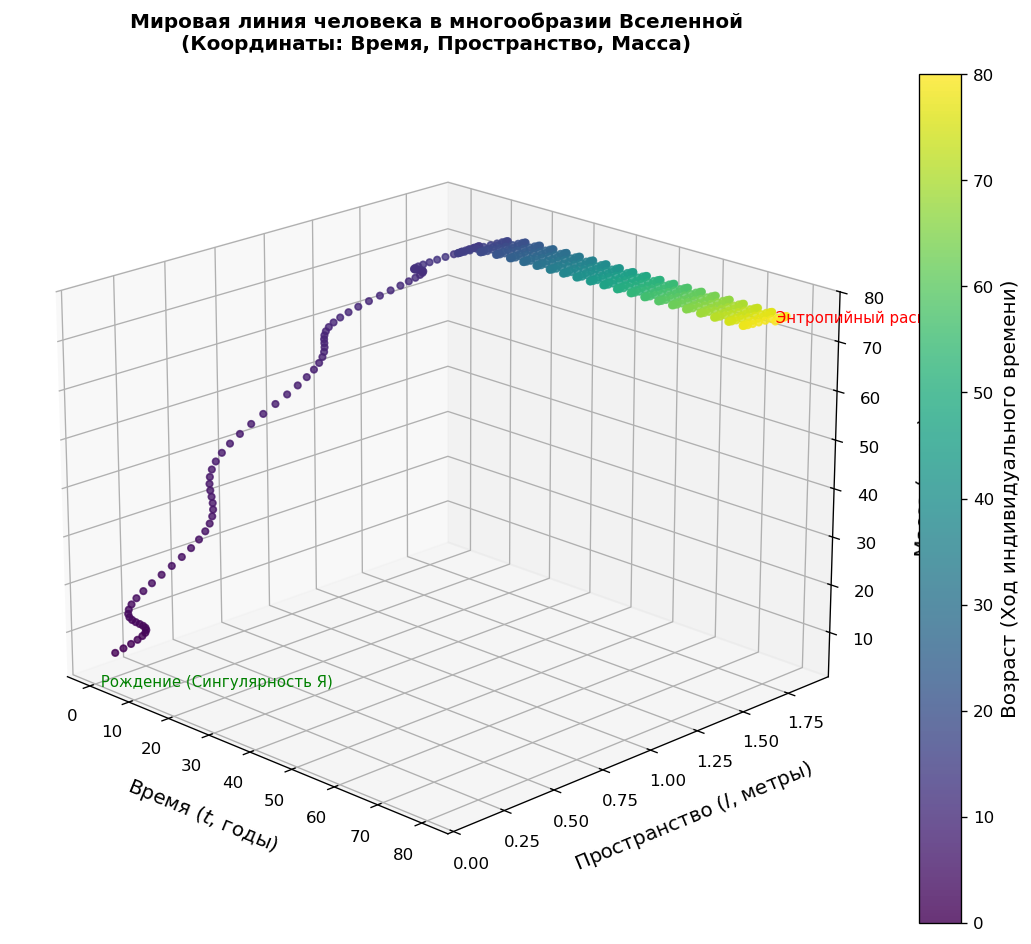

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Инициализация временной шкалы жизни (от 0 до 80 лет)
t_life = np.linspace(0, 80, 500)

# 1. Моделирование массы m(t) — быстрый рост, плато, финал
# Используем сигмоидальную функцию для фазы роста
m_max = 75.0  # Средняя масса человека в кг
m = m_max / (1 + np.exp(-0.5 * (t_life - 5))) 

# 2. Моделирование пространства l(t) — физический рост + микроперемещения
l_height = 1.75 / (1 + np.exp(-0.4 * (t_life - 7))) # Рост человека в метрах
# Добавим синусоидальную флуктуацию — это "активность/перемещения" человека в пространстве
l_activity = l_height + 0.1 * np.sin(t_life * 2) 

# Построение 3D-концепта
fig = plt.figure(figsize=(10, 8), dpi=120)
ax = fig.add_subplot(111, projection='3d')

# Рисуем мировую линию человека (траекторию бытия)
# Для красоты применим градиент цвета, зависящий от возраста (времени)
sc = ax.scatter(t_life, l_activity, m, c=t_life, cmap='viridis', s=15, alpha=0.8)

# Оформление осей в соответствии с Вашим запросом
ax.set_xlabel('Время ($t$, годы)', labelpad=10)
ax.set_ylabel('Пространство ($l$, метры)', labelpad=10)
ax.set_zlabel('Масса ($m$, кг)', labelpad=10)

ax.set_title('Мировая линия человека в многообразии Вселенной\n(Координаты: Время, Пространство, Масса)', 
             fontsize=12, fontweight='bold', pad=15)

# Добавим философские маркеры на график
ax.text(0, 0, 0, " Рождение (Сингулярность Я)", color='green', fontsize=9)
ax.text(80, 1.75, 75, " Энтропийный распад", color='red', fontsize=9)

# Настройка угла обзора для лучшего восприятия "объема" жизни
ax.view_init(elev=20, azim=-45)

plt.colorbar(sc, label='Возраст (Ход индивидуального времени)')
plt.tight_layout()
plt.show()
